# Figure 2 - Multilayer learning: Backprop vs Hebb

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gs
import h5py

import EIANN.utils as ut
import EIANN.plot as pt
from EIANN.generate_figures import *

pt.update_plot_defaults()
root_dir = ut.get_project_root()

%load_ext autoreload
%autoreload 2

/Users/ag1880/github-repos/Milstein-Lab/EIANN/EIANN/utils/data_utils.py:6: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [117]:
def generate_figure_2(model_dict_all, model_list, figure_name, figsize=(6.5, 3.8)):
    fig = plt.figure(figsize=figsize)
    axes = gs.GridSpec(nrows=3, ncols=len(model_list), figure=fig,                    
                        left=0.06,right=0.72,
                        top=0.95, bottom=0.05,
                        wspace=0.2, hspace=0.4)
    axes_metrics = gs.GridSpec(nrows=3, ncols=1, figure=fig,
                        left=0.82,right=0.99,
                        top=0.95, bottom=0.05,
                        wspace=0.2, hspace=0.4)

    ax_accuracy    = fig.add_subplot(axes_metrics[0])  
    ax_sparsity   = fig.add_subplot(axes_metrics[1])
    ax_selectivity = fig.add_subplot(axes_metrics[2])
    root_dir = ut.get_project_root()

    for col, model_key in enumerate(model_list):
        model_dict = model_dict_all[model_key]
        network_name = model_dict['config'].split('.')[0]
        hdf5_path = root_dir + f"/EIANN/data/model_hdf5_plot_data/plot_data_{network_name}.h5"
        with h5py.File(hdf5_path, 'r') as f:
            data_dict = f[network_name]
            print(f"Generating plots for {model_dict['label']}")

            plot_accuracy_all_seeds(data_dict, model_dict, ax=ax_accuracy, legend=True)

            # plot_metric_all_seeds(data_dict, model_dict, populations_to_plot=['H1E'], ax=ax_sparsity, metric_name='sparsity')
            # ax_sparsity.set_xticklabels([])
            # plot_metric_all_seeds(data_dict, model_dict, populations_to_plot=['H1E'], ax=ax_selectivity, metric_name='selectivity')
            

            #########################################################
            # Plot sparsity and selectivity bar charts
            #########################################################
            bar_width = 0.2
            group_spacing = 0.5
            within_group_spacing = 0.25
            sparsity_all_seeds = {'InputE':[], 'H1E':[], 'H2E':[]}
            selectivity_all_seeds = {'InputE':[], 'H1E':[], 'H2E':[]}
            for seed in data_dict:
                for population in sparsity_all_seeds:
                    avg_sparsity = np.mean(data_dict[seed][f"metrics_dict"][population]["sparsity"][:])
                    sparsity_all_seeds[population].append(avg_sparsity)
                    avg_selectivity = np.mean(data_dict[seed][f"metrics_dict"][population]["selectivity"][:])
                    selectivity_all_seeds[population].append(avg_selectivity)

            input_sparsity_data = sparsity_all_seeds['InputE']
            input_selectivity_data = selectivity_all_seeds['InputE']
            print(input_sparsity_data[0], input_selectivity_data[0])
            if col == 0: # Plot InputE bar
                ax_sparsity.bar(0, np.mean(input_sparsity_data), color='gray', width=bar_width, alpha=0.5, 
                            error_kw={'ecolor': 'black', 'capsize': 3})
                ax_selectivity.bar(0, np.mean(input_selectivity_data), color='gray', width=bar_width, alpha=0.5, error_kw={'ecolor': 'black', 'capsize': 3})

            x1 = group_spacing + col * within_group_spacing
            x2 = 2 * group_spacing + (len(model_list) - 1)*within_group_spacing + col*within_group_spacing
            
            ax_sparsity.bar(x1, np.mean(sparsity_all_seeds['H1E']), yerr=np.std(sparsity_all_seeds['H1E']), color=model_dict["color"], width=bar_width, alpha=0.5)
            ax_sparsity.bar(x2, np.mean(sparsity_all_seeds['H2E']), yerr=np.std(sparsity_all_seeds['H2E']), color=model_dict["color"], width=bar_width, alpha=0.5)
            ax_selectivity.bar(x1, np.mean(selectivity_all_seeds['H1E']), yerr=np.std(selectivity_all_seeds['H1E']), color=model_dict["color"], width=bar_width, alpha=0.5)
            ax_selectivity.bar(x2, np.mean(selectivity_all_seeds['H2E']), yerr=np.std(selectivity_all_seeds['H2E']), color=model_dict["color"], width=bar_width, alpha=0.5)

            h1e_center = group_spacing + (len(model_list) - 1) * within_group_spacing / 2
            h2e_center = 2 * group_spacing + (len(model_list) - 1) * within_group_spacing + (len(model_list) - 1) * within_group_spacing / 2

            ax_sparsity.set_xticks([0, h1e_center, h2e_center])
            ax_sparsity.set_xticklabels(['Input', 'H1E', 'H2E'], rotation=0, ha='center')
            ax_sparsity.set_ylabel('Sparsity')
            ax_sparsity.set_ylim([0.5, 1])
            ax_sparsity.tick_params(axis='x', length=0)

            ax_selectivity.set_xticks([0, h1e_center, h2e_center])
            ax_selectivity.set_xticklabels(['Input', 'H1E', 'H2E'], rotation=0, ha='center')
            ax_selectivity.set_ylabel('Selectivity')
            ax_selectivity.set_ylim([0.5, 1])
            ax_selectivity.tick_params(axis='x', length=0)


            #########################################################
            # Example heatmaps for E populations
            #########################################################
            example_seed = model_dict['seeds'][0]
            for row, population in enumerate(['OutputE', 'H1E']):
                # Activity plots: batch accuracy of each population to the test dataset
                ax = fig.add_subplot(axes[row, col])
                average_pop_activity_dict = data_dict[example_seed]['average_pop_activity_dict']
                num_units = average_pop_activity_dict[population].shape[1]
                pt.plot_batch_accuracy_from_data(average_pop_activity_dict, population=population, sort=True, ax=ax, cbar=True)    
                ax.set_yticks([0,num_units-1])
                ax.set_yticklabels([1,num_units])
                if col == 0:
                    ax.set_ylabel(f'{population} unit', labelpad=-7)
                else:
                    ax.set_yticklabels([])
                    ax.set_ylabel('')
                    if col == len(model_list)-1:
                        cbar = ax._colorbars[0]
                        cbar.set_label('Average activity', rotation=270, labelpad=8)        
                if row == 0:
                    ax.set_title(model_dict["display_name"])

            #########################################################
            # Class confusion bar graphs
            #########################################################
            population = 'H1E'
            between_class_similarity = {label: [] for label in range(10)}
            between_class_similarity_all = []
            for seed in model_dict['seeds']:
                # Calculate the receptive field similarity for each unit (the histogram will pool data across all model seeds)
                unit_labels_dict = data_dict[seed]['unit_labels_dict']
                unit_labels = unit_labels_dict[population][:]
                idx = np.argsort(unit_labels)
                unit_labels = unit_labels[idx]

                average_pop_activity = np.array(data_dict[seed]['average_pop_activity_dict'][population][:]).T
                sorted_pop_activity = average_pop_activity[idx]

                # Calculate within-class and between-class receptive field similarity (accumulate across all seeds)
                for label in range(10):
                    class_idx = np.where(unit_labels == label)[0]
                    max_activity_outside_class = np.max(sorted_pop_activity[class_idx][:, np.arange(10)!=label], axis=1)
                    mean_activity_outside_class = np.mean(sorted_pop_activity[class_idx][:, np.arange(10)!=label], axis=1)
                    confusion_ratio = max_activity_outside_class / (mean_activity_outside_class + 1e-10)
                    between_class_similarity_all.extend(confusion_ratio)
                    between_class_similarity[label].extend(confusion_ratio)

            ax = fig.add_subplot(axes[2, col])
            for label in range(10):
                mean_val = np.mean(between_class_similarity[label])
                std_val = np.std(between_class_similarity[label])
                ax.bar(label, mean_val, width=0.8, label='Between-class' if label==0 else None, color=model_dict["color"], alpha=0.3)
                ax.errorbar(label, mean_val, yerr=std_val, fmt='none', ecolor=model_dict["color"], capsize=0, linewidth=0.5)
            if col == 0:
                ax.set_ylabel('Confusion ratio (max/mean \nout-of-class activity)')
            ax.set_xticks(range(10))
            ax.set_xticklabels(range(10))
            ax.set_ylim(0, 8)

    fig.savefig(f"{root_dir}/EIANN/figures/{figure_name}.svg", dpi=300)
    fig.savefig(f"{root_dir}/EIANN/figures/{figure_name}.png", dpi=300)

Generating plots for Backprop (ANN)
0.84669954 0.69782364
Generating plots for Backprop (EIANN)
0.84669954 0.69782364
Generating plots for Hebb (EIANN)
0.84669954 0.69782364


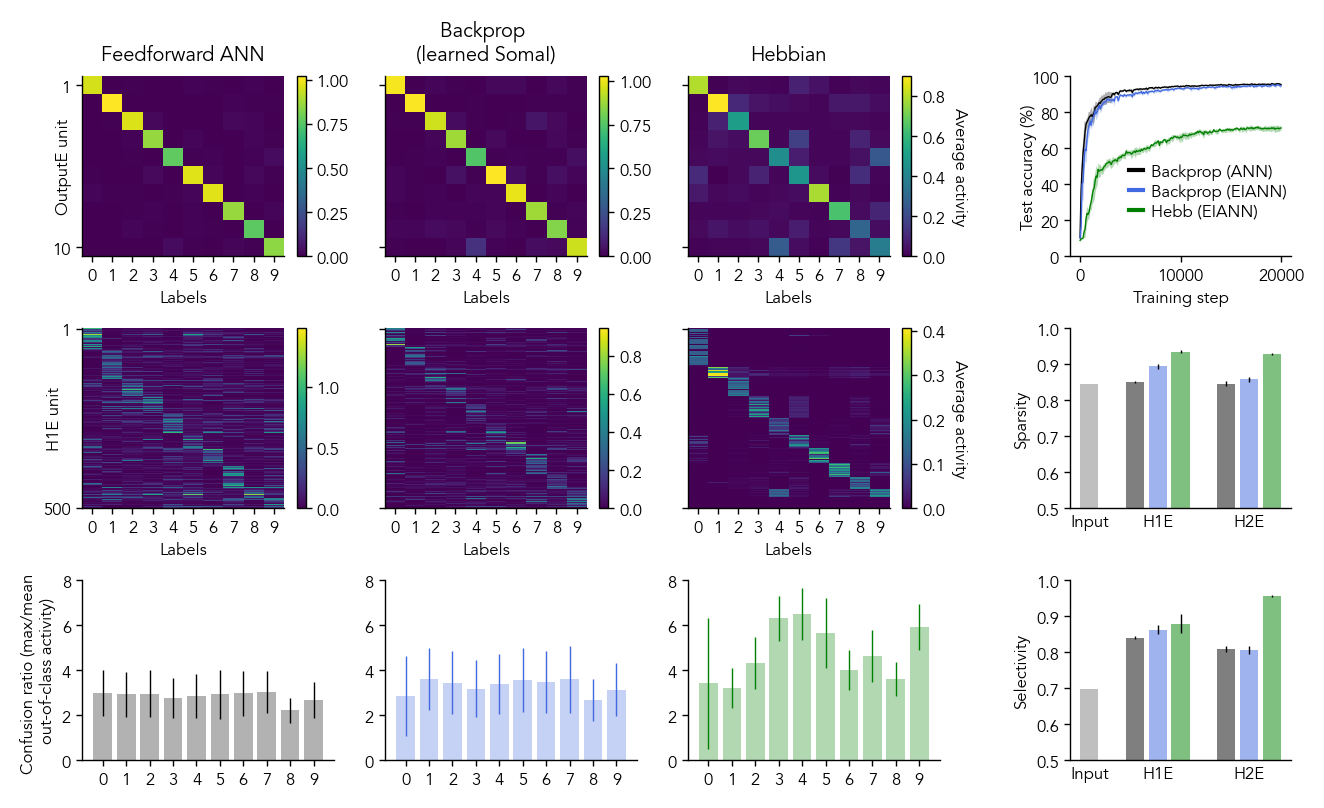

In [118]:
figure_name = "Fig2_vanBP_bpDale_hebb"
model_list = ["vanBP", "bpDale_learned", "HebbWN_topsup"]
model_dict_all = load_model_dict()
generate_hdf5_all_seeds(model_list, model_dict_all, recompute=None)

generate_figure_2(model_dict_all, model_list, figure_name)

# Supplementary Figure

In [ ]:
figure_name = "Fig2_supplementary"
model_list = ["vanBP", "bpDale_learned", "bpDale_fixed", "HebbWN_topsup", "bpLike_WT_hebbdend"]
model_dict_all = load_model_dict()
generate_hdf5_all_seeds(model_list, model_dict_all, recompute=None)

In [ ]:
def generate_figure_2_supplementary(model_dict_all, model_list, figure_name, figsize=(6.5, 6)):
    fig = plt.figure(figsize=figsize)
    axes = gs.GridSpec(nrows=6, ncols=len(model_list), figure=fig,                    
                        left=0.06,right=0.74,
                        top=0.95, bottom=0.1,
                        wspace=0.2, hspace=0.5)
    axes_metrics = gs.GridSpec(nrows=4, ncols=1, figure=fig,
                        left=0.82,right=0.99,
                        top=0.95, bottom=0.1,
                        wspace=0.2, hspace=0.6)

    ax_accuracy    = fig.add_subplot(axes_metrics[0])  
    ax_sparsity   = fig.add_subplot(axes_metrics[2])
    ax_selectivity = fig.add_subplot(axes_metrics[3])
    root_dir = ut.get_project_root()

    for col, model_key in enumerate(model_list):
        model_dict = model_dict_all[model_key]
        network_name = model_dict['config'].split('.')[0]
        hdf5_path = root_dir + f"/EIANN/data/model_hdf5_plot_data/plot_data_{network_name}.h5"
        with h5py.File(hdf5_path, 'r') as f:
            data_dict = f[network_name]
            print(f"Generating plots for {model_dict['label']}")

            plot_accuracy_all_seeds(data_dict, model_dict, ax=ax_accuracy, legend=True)

            #########################################################
            # Plot sparsity and selectivity bar charts
            #########################################################
            bar_width = 0.2
            group_spacing = 0.5
            within_group_spacing = 0.25
            sparsity_all_seeds = {'InputE':[], 'H1E':[], 'H2E':[]}
            selectivity_all_seeds = {'InputE':[], 'H1E':[], 'H2E':[]}
            for seed in data_dict:
                for population in sparsity_all_seeds:
                    avg_sparsity = np.mean(data_dict[seed][f"metrics_dict_{population}"]["sparsity"])
                    sparsity_all_seeds[population].append(avg_sparsity)
                    avg_selectivity = np.mean(data_dict[seed][f"metrics_dict_{population}"]["selectivity"])
                    selectivity_all_seeds[population].append(avg_selectivity)
            if col == 0: # Plot InputE bar
                input_sparsity_data = sparsity_all_seeds['InputE']
                input_selectivity_data = selectivity_all_seeds['InputE']
                ax_sparsity.bar(0, np.mean(input_sparsity_data), color='gray', width=bar_width, alpha=0.5, 
                            error_kw={'ecolor': 'black', 'capsize': 3})
                ax_selectivity.bar(0, np.mean(input_selectivity_data), color='gray', width=bar_width, alpha=0.5, 
                                error_kw={'ecolor': 'black', 'capsize': 3})
            x1 = group_spacing + col * within_group_spacing
            x2 = 2 * group_spacing + (len(model_list) - 1)*within_group_spacing + col*within_group_spacing
            
            ax_sparsity.bar(x1, np.mean(sparsity_all_seeds['H1E']), yerr=np.std(sparsity_all_seeds['H1E']), color=model_dict["color"], width=bar_width, alpha=0.5)
            ax_sparsity.bar(x2, np.mean(sparsity_all_seeds['H2E']), yerr=np.std(sparsity_all_seeds['H2E']), color=model_dict["color"], width=bar_width, alpha=0.5)
            ax_selectivity.bar(x1, np.mean(selectivity_all_seeds['H1E']), yerr=np.std(selectivity_all_seeds['H1E']), color=model_dict["color"], width=bar_width, alpha=0.5)
            ax_selectivity.bar(x2, np.mean(selectivity_all_seeds['H2E']), yerr=np.std(selectivity_all_seeds['H2E']), color=model_dict["color"], width=bar_width, alpha=0.5)

            h1e_center = group_spacing + (len(model_list) - 1) * within_group_spacing / 2
            h2e_center = 2 * group_spacing + (len(model_list) - 1) * within_group_spacing + (len(model_list) - 1) * within_group_spacing / 2

            ax_sparsity.set_xticks([0, h1e_center, h2e_center])
            ax_sparsity.set_xticklabels(['Input', 'H1E', 'H2E'], rotation=0, ha='center')
            ax_sparsity.set_ylabel('Sparsity')
            ax_sparsity.set_ylim([0, 1])
            ax_sparsity.tick_params(axis='x', length=0)

            ax_selectivity.set_xticks([0, h1e_center, h2e_center])
            ax_selectivity.set_xticklabels(['Input', 'H1E', 'H2E'], rotation=0, ha='center')
            ax_selectivity.set_ylabel('Selectivity')
            ax_selectivity.set_ylim([0, 1])
            ax_selectivity.tick_params(axis='x', length=0)


            ####################################################################
            # Example heatmaps and class confusion bar graphs for E populations
            ####################################################################
            example_seed = model_dict['seeds'][0]
            row = 0
            for population in ['OutputE', 'H2E', 'H1E']:
                ax = fig.add_subplot(axes[row, col])
                row += 1
                # Activity heatmaps
                average_pop_activity_dict = data_dict[example_seed]['average_pop_activity_dict']
                num_units = average_pop_activity_dict[population].shape[1]
                pt.plot_batch_accuracy_from_data(average_pop_activity_dict, population=population, sort=True, ax=ax, cbar=True)    
                ax.set_yticks([0,num_units-1])
                ax.set_yticklabels([1,num_units])
                if col == 0:
                    ax.set_ylabel(f'{population} unit', labelpad=-6)
                elif col > 0:
                    ax.set_yticklabels([])
                    ax.set_ylabel('')
                    if col == len(model_list)-1:
                        cbar = ax._colorbars[0]
                        cbar.set_label('Average activity', rotation=270, labelpad=8)     
                if row == 0:
                    ax.set_title(model_dict["display_name"])

                # Class confusion bar graphs
                ax = fig.add_subplot(axes[row, col])
                row += 1
                between_class_similarity = {label: [] for label in range(10)}
                between_class_similarity_all = []
                for seed in model_dict['seeds']:
                    # Calculate the receptive field similarity for each unit (the histogram will pool data across all model seeds)
                    unit_labels_dict = data_dict[seed]['unit_labels_dict']
                    unit_labels = unit_labels_dict[population][:]
                    idx = np.argsort(unit_labels)
                    unit_labels = unit_labels[idx]
                    average_pop_activity = np.array(data_dict[seed]['average_pop_activity_dict'][population][:]).T
                    sorted_pop_activity = average_pop_activity[idx]

                    # Calculate within-class and between-class receptive field similarity (accumulate across all seeds)
                    for label in range(10):
                        class_idx = np.where(unit_labels == label)[0]
                        max_activity_outside_class = np.max(sorted_pop_activity[class_idx][:, np.arange(10)!=label], axis=1)
                        mean_activity_outside_class = np.mean(sorted_pop_activity[class_idx][:, np.arange(10)!=label], axis=1)
                        confusion_ratio = max_activity_outside_class / (mean_activity_outside_class + 1e-10)
                        between_class_similarity_all.extend(confusion_ratio)
                        between_class_similarity[label].extend(confusion_ratio)
                
                for label in range(10):
                    mean_val = np.mean(between_class_similarity[label])
                    std_val = np.std(between_class_similarity[label])
                    ax.bar(label, mean_val, width=0.8, label='Between-class' if label==0 else None, color=model_dict["color"], alpha=0.4)
                    ax.errorbar(label, mean_val, yerr=std_val, fmt='none', ecolor=model_dict["color"], capsize=0, linewidth=0.5)
                if col == 0:
                    ax.set_ylabel('Confusion ratio (max/mean \nout-of-class activity)')
                ax.set_xticks(range(10))
                ax.set_xticklabels(range(10))
                ax.set_ylim(0, 8)

    fig.savefig(f"{root_dir}/EIANN/figures/{figure_name}.svg", dpi=300)
    fig.savefig(f"{root_dir}/EIANN/figures/{figure_name}.png", dpi=300)

In [ ]:
generate_figure_2_supplementary(model_dict_all, model_list, figure_name)